# Import Libraries

In [49]:
import pandas as pd               #Data Handling
import numpy as np                #Numerical operations
import matplotlib.pyplot as plt   #Visualization
import seaborn as sns             #Visualization

#preprocessing
from sklearn.preprocessing import LabelEncoder        #Convert categorical data into numbers
from sklearn.model_selection import train_test_split  #Split dataset for training and testing

#Model
from sklearn.tree import DecisionTreeClassifier, plot_tree      #Decision Tree Classifier (ML model)
from sklearn.model_selection import GridSearchCV      #Hyperparameter tuning

#Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Model Saving
import joblib


# Upload asia air quality file

In [50]:
from google.colab import files
uploaded = files.upload()

Saving asia_air_quality_data.xlsx to asia_air_quality_data (1).xlsx


# Upload dataset

In [51]:
df = pd.read_excel('asia_air_quality_data.xlsx')
df.head()

,Country,City,Date,Season,Industrial_Index,Traffic_Index,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind_Speed,AQI,AQI_Category
0,China,Shanghai,2022-12-15,Winter,34.674783,84.578370,196.447335,344.504607,100.547834,23.095686,5.096223,30.001355,31.035539,24.230868,18.327971,207.486735,Very Poor
1,China,Beijing,2022-07-11,Monsoon,99.376925,73.223706,293.765213,407.598690,82.550273,78.914162,5.616570,42.587988,8.624257,66.378951,10.179088,264.545428,Very Poor
2,India,Kolkata,2022-11-03,Autumn,74.424603,61.534948,192.556736,307.998438,81.633864,54.034194,4.413742,126.647288,11.934586,49.329546,5.373666,201.543834,Very Poor
3,India,Chennai,2022-01-02,Winter,54.012470,44.555916,193.282367,263.028436,51.704243,49.214440,3.199551,139.732241,34.090880,44.490558,14.690655,179.704626,Poor
4,China,Guangzhou,2022-08-01,Monsoon,51.094183,48.994432,137.166428,241.327152,62.229502,32.060146,2.989293,122.307577,7.982026,94.016520,19.533874,150.214534,Poor


# Understand Data / Statistical analysis

In [52]:
df.shape      #shows number of rows and columns

(30000, 17)

In [53]:
df.info()     #shows datatype and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Country           30000 non-null  object        
 1   City              30000 non-null  object        
 2   Date              30000 non-null  datetime64[ns]
 3   Season            30000 non-null  object        
 4   Industrial_Index  30000 non-null  float64       
 5   Traffic_Index     30000 non-null  float64       
 6   PM2.5             30000 non-null  float64       
 7   PM10              30000 non-null  float64       
 8   NO2               30000 non-null  float64       
 9   SO2               30000 non-null  float64       
 10  CO                30000 non-null  float64       
 11  O3                30000 non-null  float64       
 12  Temperature       30000 non-null  float64       
 13  Humidity          30000 non-null  float64       
 14  Wind_Speed        3000

In [54]:
df.describe()   #Statistical summary

,Date,Industrial_Index,Traffic_Index,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind_Speed,AQI
count,30000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,2022-07-02 13:24:28.800000256,60.205004,65.183478,214.717472,304.459724,78.248735,48.198735,4.410802,79.897825,25.015284,57.627985,12.947622,204.202379
min,2022-01-01 00:00:00,20.000184,30.004977,20.302464,22.349890,4.748295,0.830368,1.820925,10.000319,5.000455,20.000167,1.000351,48.266174
25%,2022-04-02 00:00:00,40.383524,47.565478,163.779418,235.663215,57.241870,32.382892,3.528184,45.273979,14.979758,38.948283,6.905642,165.637581
50%,2022-07-02 00:00:00,60.161621,65.265158,211.646223,302.736156,78.296029,48.286397,4.415635,79.690209,25.109016,57.719965,12.963830,202.955764
75%,2022-10-02 00:00:00,80.272615,82.862947,261.022759,371.263529,99.408662,64.237524,5.290723,114.925728,34.951985,76.353115,18.927140,241.532524
max,2022-12-31 00:00:00,99.998222,99.993748,486.430633,659.038845,154.783736,99.451371,6.957392,149.996636,44.998955,94.999204,24.999448,392.222732
std,NaN,23.087386,20.258044,70.653526,96.587260,26.288835,19.134498,1.128705,40.316956,11.542702,21.615166,6.936671,54.413539


# check missing values

In [55]:
df.isnull().sum()

,0
Country,0
City,0
Date,0
Season,0
Industrial_Index,0
Traffic_Index,0
PM2.5,0
PM10,0
NO2,0
SO2,0


# EDA

In [56]:
#AQI category percentagewise distribution
aqi_percentage = df["AQI_Category"].value_counts(normalize= True)*100
aqi_percentage = aqi_percentage.reset_index()
aqi_percentage.columns = ["AQI_Category", "Percentage"]
aqi_percentage

,AQI_Category,Percentage
0,Very Poor,47.766667
1,Poor,45.883333
2,Severe,4.326667
3,Moderate,2.016667
4,Good,0.006667


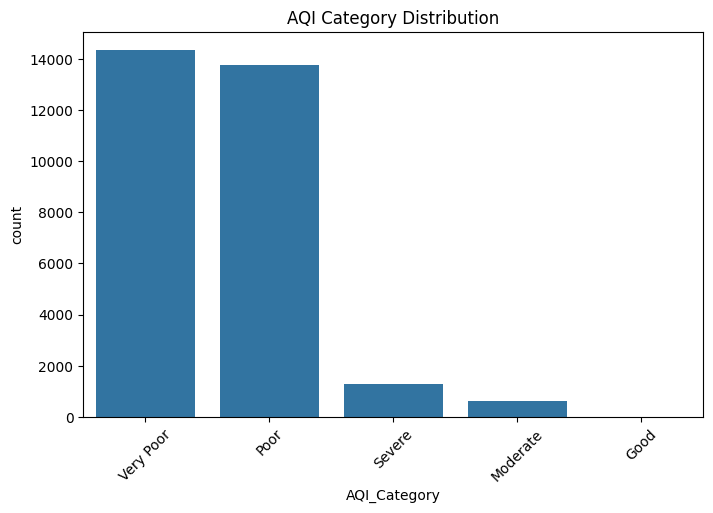

In [57]:
#AQI_category (Target variable) distribution
plt.figure(figsize=(8,5))
sns.countplot(x='AQI_Category', data=df)
plt.title('AQI Category Distribution')
plt.xticks(rotation=45)
plt.show()

In [58]:
#Numerical feature distribution
numerical_cols = df.select_dtypes(include=['number']).columns
numerical_cols

Index(['Industrial_Index', 'Traffic_Index', 'PM2.5', 'PM10', 'NO2', 'SO2',
       'CO', 'O3', 'Temperature', 'Humidity', 'Wind_Speed', 'AQI'],
      dtype='object')

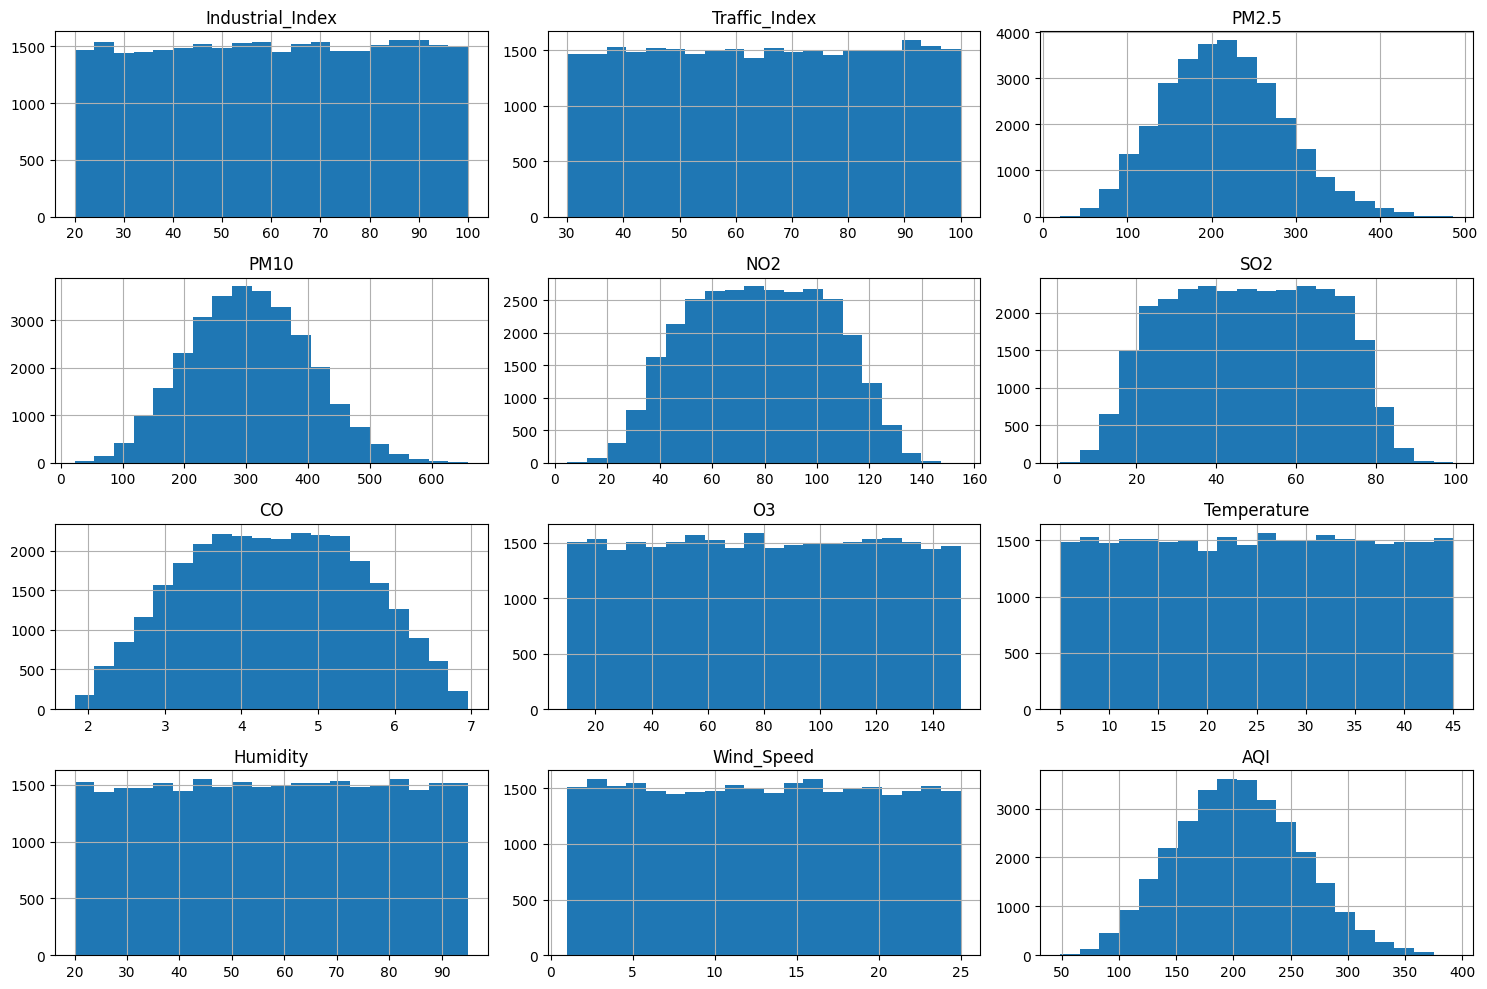

In [59]:
df[numerical_cols].hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

In [60]:
#categorical feature analysis

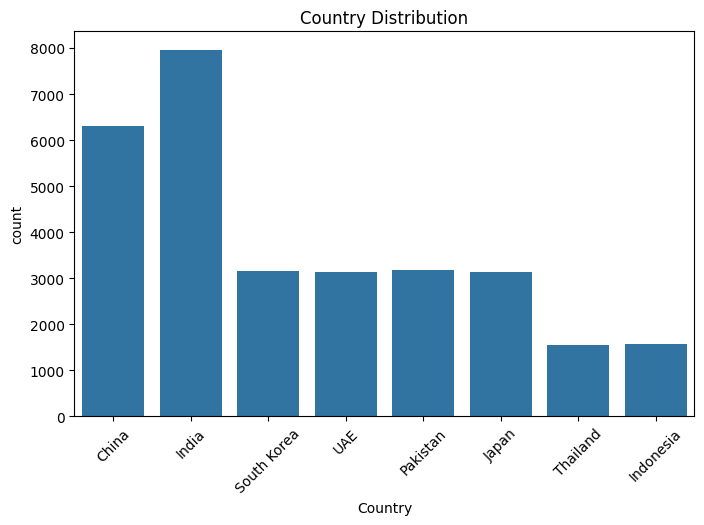

In [61]:
#Country Distribution
plt.figure(figsize=(8,5))
sns.countplot(x='Country', data=df)
plt.title("Country Distribution")
plt.xticks(rotation=45)
plt.show()

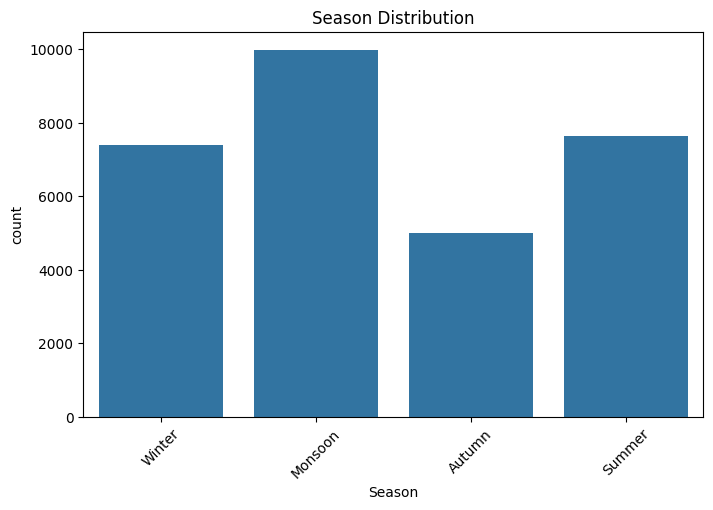

In [62]:
#Seasonal distribution
plt.figure(figsize=(8,5))
sns.countplot(x='Season', data=df)
plt.title("Season Distribution")
plt.xticks(rotation=45)
plt.show()

In [63]:
#Seasonal impact on AQI

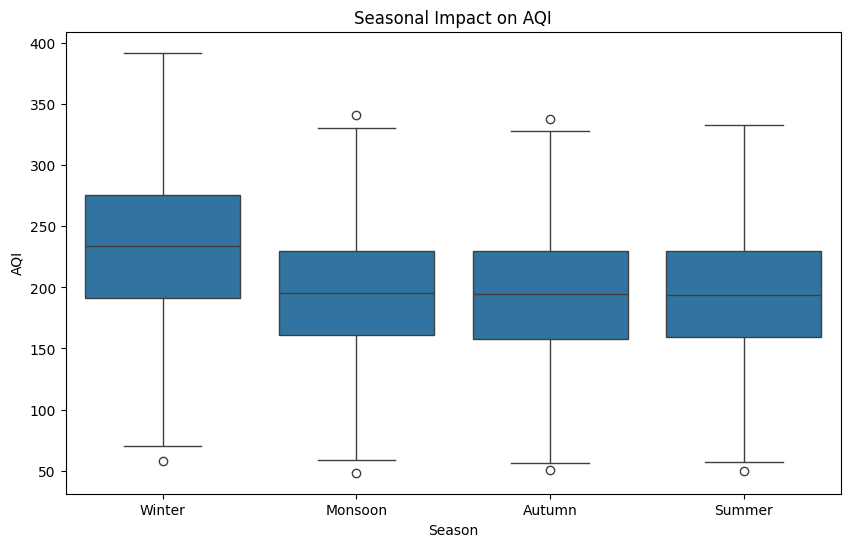

In [64]:
#Seasonal impact on AQI
plt.figure(figsize=(10, 6))
sns.boxplot(x='Season', y='AQI', data=df)
plt.title('Seasonal Impact on AQI')
plt.xlabel('Season')
plt.ylabel('AQI')
plt.show()

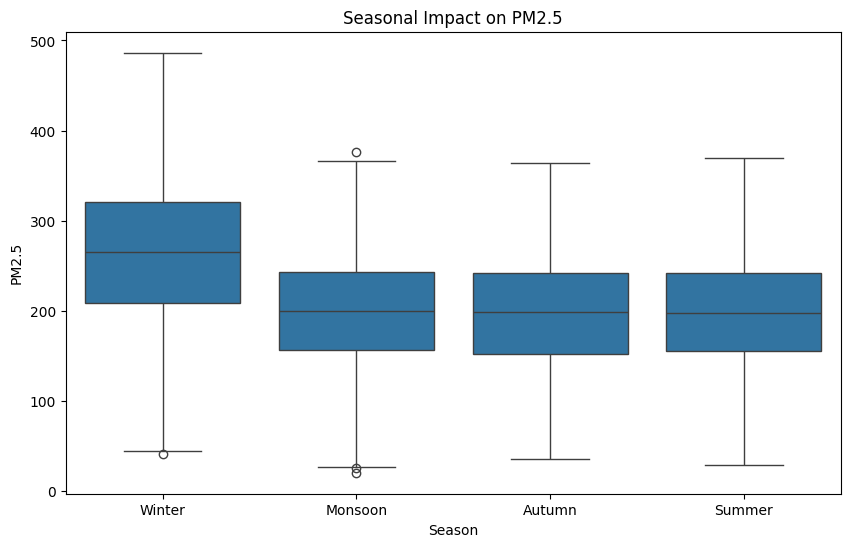

In [65]:
#pollutants by season
plt.figure(figsize=(10, 6))
sns.boxplot(x='Season', y='PM2.5', data=df)
plt.title('Seasonal Impact on PM2.5')
plt.xlabel('Season')
plt.ylabel('PM2.5')
plt.show()

In [66]:
#Correlation analysis

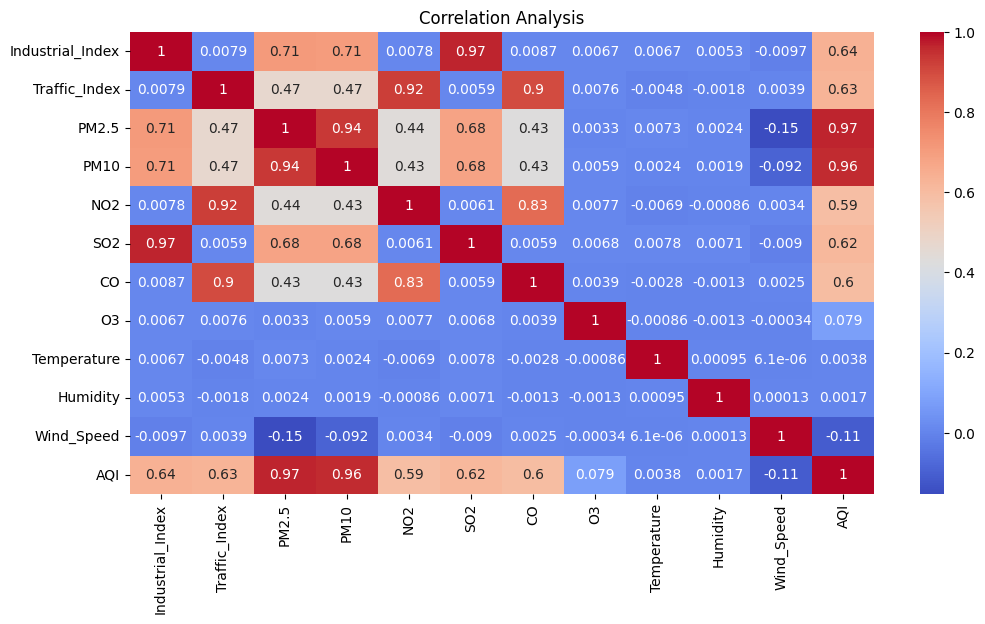

In [67]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(numeric_only= True), annot=True, cmap='coolwarm')
plt.title('Correlation Analysis')
plt.show()

In [68]:
df.corr(numeric_only= True)["AQI"].sort_values(ascending=False)

,AQI
AQI,1.000000
PM2.5,0.966161
PM10,0.955748
Industrial_Index,0.637631
Traffic_Index,0.627910
SO2,0.616249
CO,0.598373
NO2,0.591804
O3,0.079244
Temperature,0.003787


In [69]:
#Human activity analysis

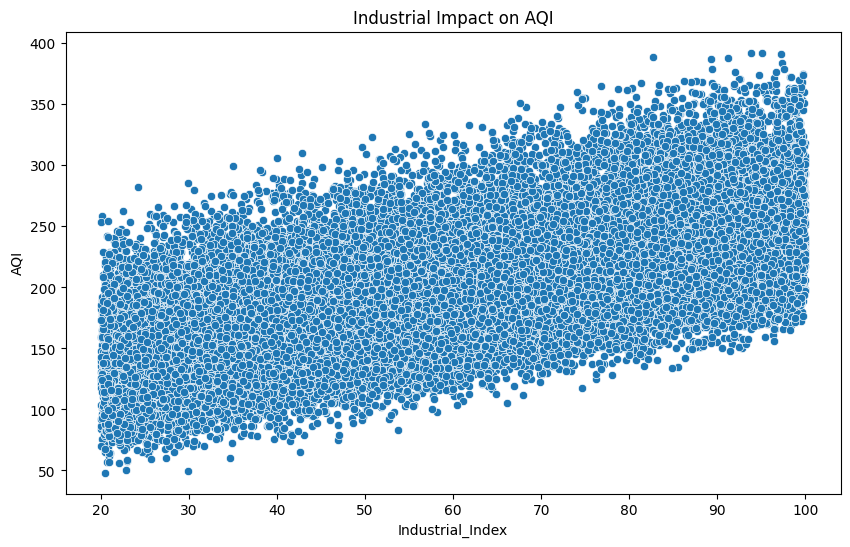

In [70]:
#industrial impact on AQI
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Industrial_Index', y='AQI', data=df)
plt.title('Industrial Impact on AQI')
plt.show()

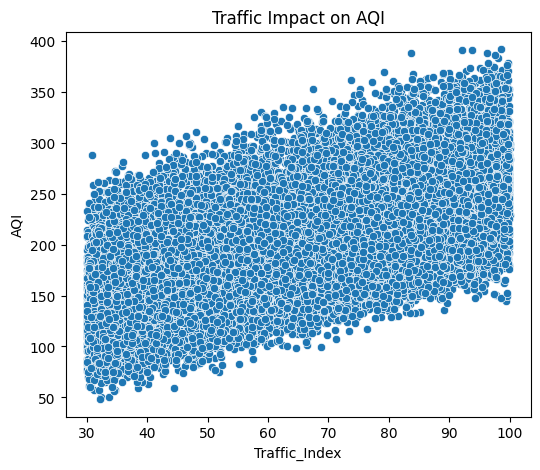

In [71]:
#Traffic index on AQI
plt.figure(figsize=(6,5))
sns.scatterplot(x = 'Traffic_Index', y = 'AQI', data = df)
plt.title('Traffic Impact on AQI')
plt.show()

In [72]:
#Meteorological Features vs Pollutant ConcentraƟon Features

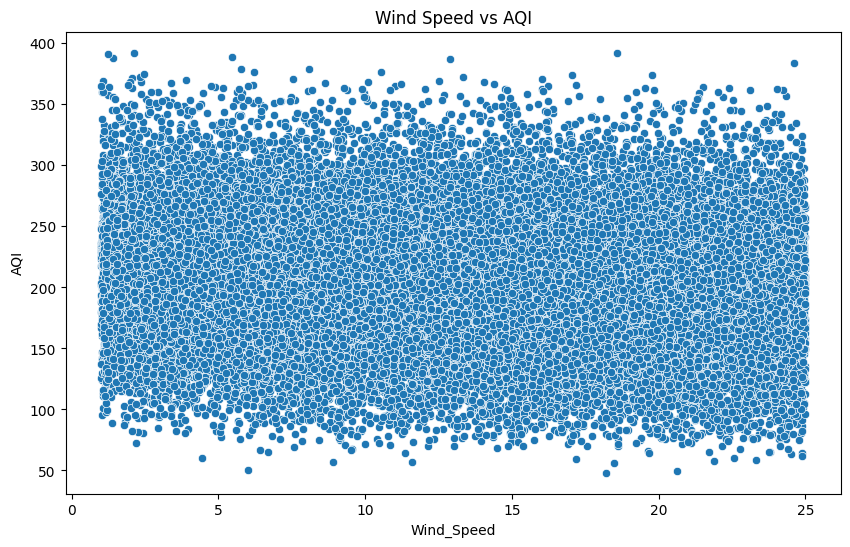

In [73]:
#Wind speed vs AQI
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Wind_Speed', y='AQI', data=df)
plt.title('Wind Speed vs AQI')
plt.show()

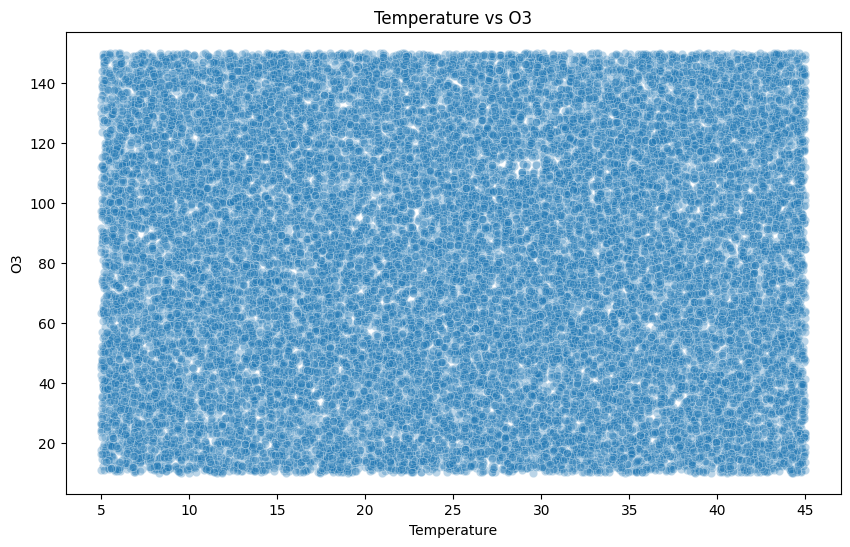

In [74]:
#Temperature vs O3
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature', y='O3', data=df, alpha= 0.3)
plt.title('Temperature vs O3')
plt.show()

This shows that there is no linear relationship between temperature and O3.

In [75]:
df[["Temperature", "O3"]].corr()

,Temperature,O3
Temperature,1.000000,-0.000863
O3,-0.000863,1.000000


correlation b/w Temp and O3 is -0.000863 which means there is no relationship in temp and o3.

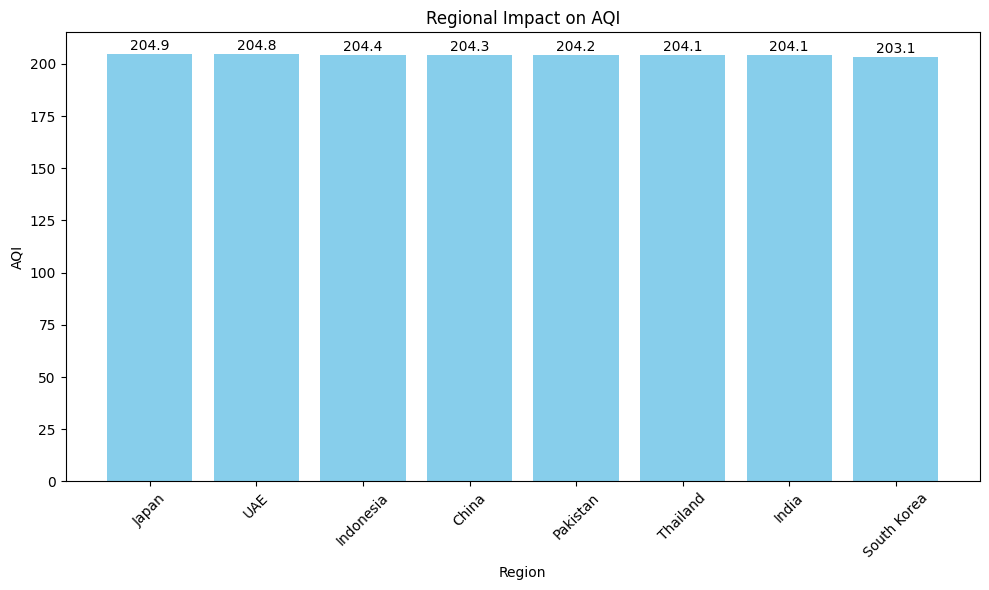

In [76]:
#Regional vs AQI & category
df["AQI"] = pd.to_numeric(df["AQI"], errors='coerce')  #making AQI value numeric, if no value then NaN
df["AQI"]

df_clean = df.dropna(subset=["AQI"])   #delete in case value is missing
df_clean["AQI"]

region_aqi = df_clean.groupby("Country")["AQI"].mean().sort_values(ascending=False)   #group by country and calculate mean AQI
region_aqi


plt.figure(figsize=(10, 6))                                             #plot creation
bars = plt.bar(region_aqi.index, region_aqi.values, color='skyblue')

for bar in bars:                                                        #data labelling
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height+0.5,
        f'{height:.1f}',
        ha='center',
        va='bottom',
        fontsize=10
    )


plt.title('Regional Impact on AQI')
plt.xlabel('Region')
plt.ylabel('AQI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Data Preprocessing

In [77]:
#Dropping Date column as it is not needed
df = df.drop(["Date"], axis=1)
df.head()

,Country,City,Season,Industrial_Index,Traffic_Index,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind_Speed,AQI,AQI_Category
0,China,Shanghai,Winter,34.674783,84.578370,196.447335,344.504607,100.547834,23.095686,5.096223,30.001355,31.035539,24.230868,18.327971,207.486735,Very Poor
1,China,Beijing,Monsoon,99.376925,73.223706,293.765213,407.598690,82.550273,78.914162,5.616570,42.587988,8.624257,66.378951,10.179088,264.545428,Very Poor
2,India,Kolkata,Autumn,74.424603,61.534948,192.556736,307.998438,81.633864,54.034194,4.413742,126.647288,11.934586,49.329546,5.373666,201.543834,Very Poor
3,India,Chennai,Winter,54.012470,44.555916,193.282367,263.028436,51.704243,49.214440,3.199551,139.732241,34.090880,44.490558,14.690655,179.704626,Poor
4,China,Guangzhou,Monsoon,51.094183,48.994432,137.166428,241.327152,62.229502,32.060146,2.989293,122.307577,7.982026,94.016520,19.533874,150.214534,Poor


In [78]:
#Transforming categorical data to numeric (ML models understand numbers only)
le = LabelEncoder()
df["Country"] = le.fit_transform(df["Country"])
df["City"] = le.fit_transform(df["City"])
df["Season"] = le.fit_transform(df["Season"])
df["AQI_Category"] = le.fit_transform(df["AQI_Category"])
df.head()

,Country,City,Season,Industrial_Index,Traffic_Index,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind_Speed,AQI,AQI_Category
0,0,16,3,34.674783,84.578370,196.447335,344.504607,100.547834,23.095686,5.096223,30.001355,31.035539,24.230868,18.327971,207.486735,4
1,0,3,1,99.376925,73.223706,293.765213,407.598690,82.550273,78.914162,5.616570,42.587988,8.624257,66.378951,10.179088,264.545428,4
2,1,11,0,74.424603,61.534948,192.556736,307.998438,81.633864,54.034194,4.413742,126.647288,11.934586,49.329546,5.373666,201.543834,4
3,1,5,3,54.012470,44.555916,193.282367,263.028436,51.704243,49.214440,3.199551,139.732241,34.090880,44.490558,14.690655,179.704626,2
4,0,8,1,51.094183,48.994432,137.166428,241.327152,62.229502,32.060146,2.989293,122.307577,7.982026,94.016520,19.533874,150.214534,2


# Define Features and Target

In [79]:
X = df.drop(["AQI_Category"], axis=1)
y = df["AQI_Category"]

# Train-Test Split

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42                      #80-20% training and testing data and random state ensures reproducibility (shuffle in the same order every time.)
)

# Train Decision Tree model

In [81]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Here we are creating decision rules for our model and split data based on feature.

# Predictions

In [82]:
y_pred = dt_model.predict(X_test)

# Model Evalution

In [83]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

Accuracy:  0.9998333333333334


# Hyperparameter tuning

In [84]:
param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_
print("Best Decision Tree parameter (Hyperparameters tuning):", dt_grid.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Best Decision Tree parameter (Hyperparameters tuning): {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


# Best Model

In [85]:
best_model = dt_grid.best_estimator_
y_pred_best = best_model.predict(X_test)
print("Best Model Accuracy:", accuracy_score(y_test, y_pred_best))

Best Model Accuracy: 0.9998333333333334


# Tuned model evaluation

In [86]:
#Classification report
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.99      1.00       121
           2       1.00      1.00      1.00      2784
           3       1.00      1.00      1.00       251
           4       1.00      1.00      1.00      2843

    accuracy                           1.00      6000
   macro avg       0.90      1.00      0.93      6000
weighted avg       1.00      1.00      1.00      6000



Classification report shows how well our decision tree model is performing for each AQI category.

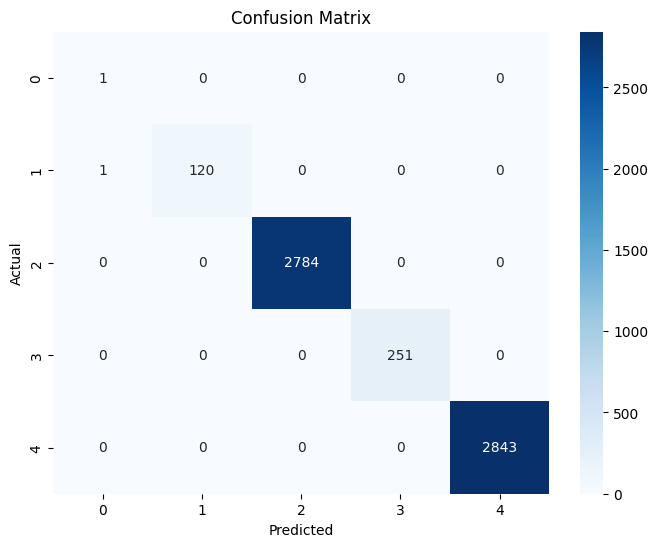

In [87]:
#Confusion report
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot= True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature Importance

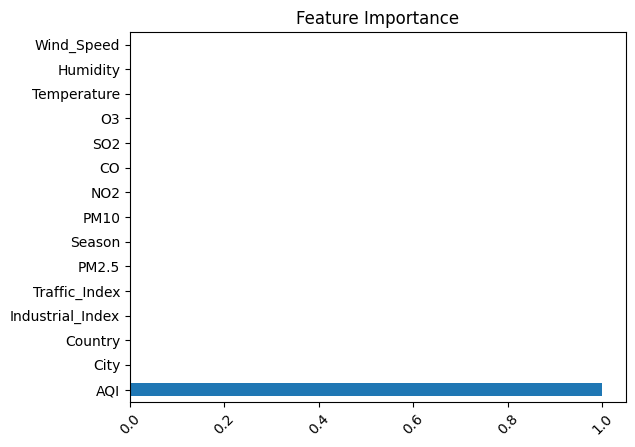

In [88]:
importance = best_model.feature_importances_

feature_importance = pd.Series(importance, index=X.columns)
feature_importance.sort_values(ascending=False).plot(kind = "barh")
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

This shows that our model is using AQI to predict AQI category and ignored other features.

# Decision tree visualization

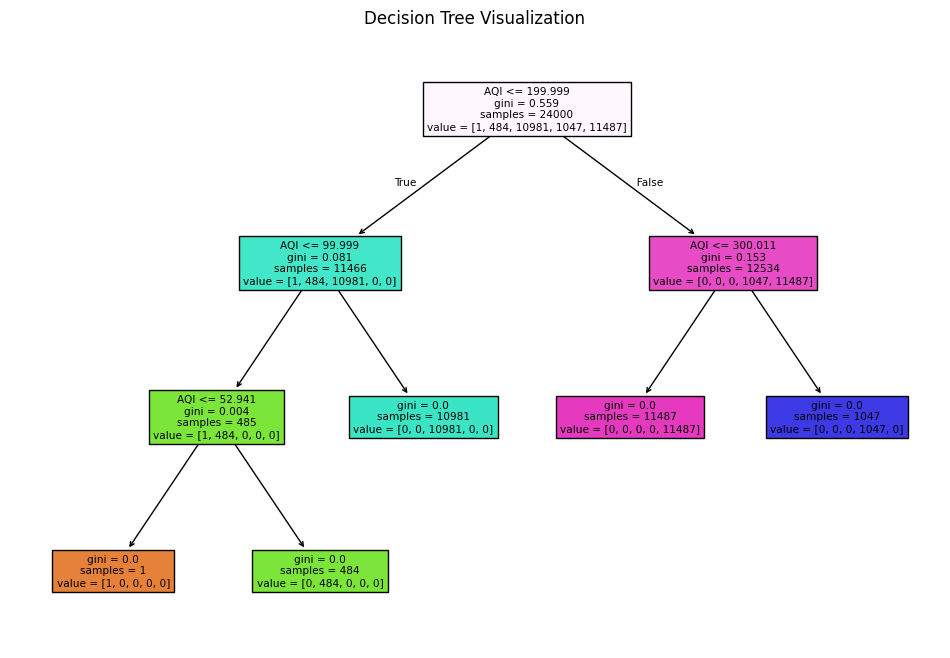

In [89]:
plt.figure(figsize=(12, 8))
plot_tree(best_model, filled=True, feature_names=X.columns, max_depth=3)
plt.title("Decision Tree Visualization")
plt.show()

# Saving Model (MLOps)

In [90]:
joblib.dump(best_model, 'AQI_analysis_decision_model.pkl')

['AQI_analysis_decision_model.pkl']

# Downloading file

In [91]:
from google.colab import files                         #its a google colab functionality, not ML logic. It downloaded google colab file to our computer
files.download('AQI_analysis_decision_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>